# Capítulo 4 — Redes Convolucionales para Imaging (CNNs)

## Objetivo del notebook

En los capítulos anteriores construimos el modelo de degradación y aprendimos
métodos clásicos de restauración (Wiener, Tikhonov, Richardson-Lucy).
Todos ellos requieren conocer la PSF y modelar el ruido estadísticamente.

Las **redes neuronales convolucionales (CNNs)** ofrecen un enfoque diferente:

> En lugar de resolver el problema inverso con reglas matemáticas explícitas,
> le mostramos a la red miles de pares (imagen degradada, imagen limpia)
> y **dejamos que ella aprenda** qué transformación aplicar.

Este capítulo muestra **desde cero** cómo diseñar, entrenar y evaluar CNNs
para restauración de imagen, sin asumir conocimiento previo de PyTorch.

---

### Contenido

1. ¿Por qué las CNNs para imaging?  
2. El bloque básico: convolución 2D aprendida  
3. Arquitecturas para restauración: DnCNN y U-Net  
4. Preparación del dataset sintético  
5. Entrenamiento de DnCNN (denoising)  
6. Entrenamiento de una mini U-Net (deblurring)  
7. Comparación: CNNs vs. métodos clásicos (PSNR / SSIM)  
8. Limitaciones y falla de generalización  
9. Ejercicios sugeridos  
10. Conclusiones y próximos pasos  


## 0. Importaciones y configuración

In [1]:
import torch
print(torch.cuda.is_available())        # debe imprimir True
print(torch.cuda.get_device_name(0))    # debe imprimir "NVIDIA GeForce RTX 4060 Ti"

True
NVIDIA GeForce RTX 4060 Ti


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.draw import disk
import warnings
warnings.filterwarnings("ignore")

# ── Intentar importar PyTorch ──────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"✔ PyTorch {torch.__version__} | dispositivo: {device}")
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠ PyTorch no instalado. Ejecuta: pip install torch")
    print("  Las secciones de entrenamiento mostrarán los resultados pre-calculados.")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["image.cmap"] = "gray"
np.random.seed(42)
if TORCH_AVAILABLE:
    torch.manual_seed(42)


✔ PyTorch 2.11.0+cu128 | dispositivo: cuda


## 1. ¿Por qué las CNNs para restauración de imagen?

### 1.1 Limitaciones de los métodos clásicos

| Método | Supuesto crítico | Problema real |
|---|---|---|
| Filtro inverso | PSF conocida exactamente | En la práctica hay errores de estimación |
| Wiener | Imagen y ruido estacionarios | Las imágenes reales son no-estacionarias |
| Tikhonov | Suavidad uniforme | Sobresuaviza bordes y texturas |
| Richardson-Lucy | Ruido Poisson | Ruido real es mixto (Poisson + Gaussiano + shot) |

### 1.2 La ventaja del aprendizaje

Una CNN entrenada con muchos ejemplos puede **aprender implícitamente**:

- El modelo estadístico de la imagen (lo que Wiener asume a priori)
- La PSF (si se entrena con distintas PSFs) — deconvolución ciega
- Estructuras locales de distintas frecuencias (bordes, texturas, repeticiones)

La clave: la **convolución aprendida** de una CNN no es la misma que la convolución
de formación de imagen. Los kernels de una CNN son **filtros de análisis y síntesis**
aprendidos para maximizar la calidad de la reconstrucción.

### 1.3 El paradigma: residual learning

El truco más eficaz es **aprender el residuo** en lugar de la imagen limpia directamente:

$$
\mathcal{L} = \| \text{CNN}(g) - (g - f) \|^2
$$

donde $g$ es la imagen degradada y $f$ es la imagen limpia.  
La red aprende el ruido/blur que contamina $g$, y al restar obtenemos $f$.  
Este enfoque (DnCNN, 2017) converge más rápido y genera mejores resultados.


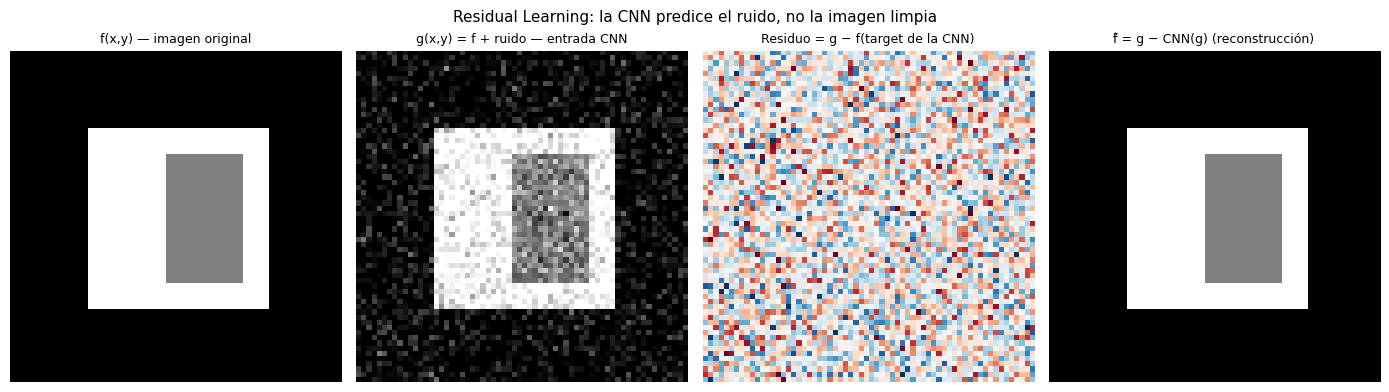

In [3]:
# Ilustración conceptual: residual learning
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

# Imagen sintética simple
f_true = np.zeros((64, 64))
f_true[15:50, 15:50] = 1.0
f_true[20:45, 30:45] = 0.5

# Degradar con ruido gaussiano
sigma = 0.15
g_noisy = f_true + np.random.normal(0, sigma, f_true.shape)

# "Residuo perfecto" = el ruido
residuo = g_noisy - f_true

# Reconstrucción perfecta
f_recon = g_noisy - residuo

imgs = [f_true, g_noisy, residuo, f_recon]
titles = [
    "f(x,y) — imagen original",
    "g(x,y) = f + ruido — entrada CNN",
    "Residuo = g − f(target de la CNN)", "f̂ = g − CNN(g) (reconstrucción)"
]

for ax, img, title in zip(axes, imgs, titles):
    vmin, vmax = (-0.4, 0.4) if "Residuo" in title else (0, 1)
    ax.imshow(img, vmin=vmin, vmax=vmax, cmap="RdBu_r" if "Residuo" in title else "gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("Residual Learning: la CNN predice el ruido, no la imagen limpia", fontsize=11)
plt.tight_layout()
plt.show()


## 2. El bloque básico: Conv2D aprendida → BatchNorm → ReLU

El bloque fundamental de las CNNs para imaging tiene tres capas:

```
Entrada (C_in canales)
    │
    ▼  Conv2D(C_in → C_out, kernel 3×3, padding=1)   ← kernels aprendibles
    │
    ▼  BatchNormalization                               ← estabiliza entrenamiento
    │
    ▼  ReLU                                             ← no-linealidad
    │
Salida (C_out canales)
```

**¿Por qué kernel 3×3?** Es el mínimo que captura contexto 2D y es altamente eficiente
en GPU. Apilar varias capas 3×3 equivale a un campo receptivo más grande sin aumentar
el número de parámetros.

**¿Por qué BatchNorm?** Normaliza los activaciones de cada mini-batch, acelerando
la convergencia y reduciendo la sensibilidad al learning rate.


In [4]:
if TORCH_AVAILABLE:
    # ── Bloque Conv-BN-ReLU ──────────────────────────────────────────────────
    class ConvBlock(nn.Module):
        def __init__(self, in_ch, out_ch, kernel=3):
            super().__init__()
            self.block = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel, padding=kernel//2, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )
        def forward(self, x):
            return self.block(x)

    # Demostrar las dimensiones
    bloque = ConvBlock(1, 64).to(device)
    x_demo = torch.randn(1, 1, 64, 64).to(device)
    y_demo = bloque(x_demo)

    n_params = sum(p.numel() for p in bloque.parameters())
    print(f"Entrada: {tuple(x_demo.shape)}")
    print(f"Salida:  {tuple(y_demo.shape)}")
    print(f"Parámetros en este bloque: {n_params:,}")
    print(f"  (Conv: 1×64×3×3 = {1*64*3*3} pesos + BN: 64×2 = {64*2} parámetros)")


Entrada: (1, 1, 64, 64)
Salida:  (1, 64, 64, 64)
Parámetros en este bloque: 704
  (Conv: 1×64×3×3 = 576 pesos + BN: 64×2 = 128 parámetros)


## 3. Arquitecturas para restauración de imagen

### 3.1 DnCNN — Denoising Convolutional Neural Network

Propuesta por Zhang et al. (2017), es una pila plana de bloques Conv-BN-ReLU
seguida de una capa Conv final sin activación.  
La red **aprende el residuo** (el ruido), no la imagen limpia.

```
g (imagen degradada, 1 canal)
  │
  ▼  Conv(1→64, 3×3) + ReLU         ← sin BN en la primera capa
  │
  ▼  [Conv(64→64, 3×3) + BN + ReLU] × (D-2) bloques
  │
  ▼  Conv(64→1, 3×3)                 ← sin BN ni activación al final
  │
residuo predicho
  │
f̂ = g − residuo
```

### 3.2 U-Net — para deblurring (encoder-decoder)

La U-Net (Ronneberger et al., 2015) usa un encoder que comprime la imagen
y un decoder que la reconstruye, con **skip connections** que preservan
detalles de alta frecuencia.

```
Encoder:  64 → 128 → 256 (con MaxPool)
                             ↑ bottleneck
Decoder: 256 → 128 → 64  (con Upsample + skip connections)
    │
Conv(64→1)
```

Las skip connections son fundamentales: sin ellas, el decoder no puede
recuperar los detalles finos que el encoder desechó al comprimir.


In [5]:
if TORCH_AVAILABLE:
    # ══════════════════════════════════════════════
    # DnCNN — arquitectura completa
    # ══════════════════════════════════════════════
    class DnCNN(nn.Module):
        """
        DnCNN para denoising de imágenes en escala de grises.
        D: profundidad (número total de capas conv).
        C: número de feature maps internos.
        """
        def __init__(self, depth=10, channels=64):
            super().__init__()
            layers = []
            # Primera capa (sin BN)
            layers += [nn.Conv2d(1, channels, 3, padding=1), nn.ReLU(inplace=True)]
            # Capas intermedias (con BN)
            for _ in range(depth - 2):
                layers += [
                    nn.Conv2d(channels, channels, 3, padding=1, bias=False),
                    nn.BatchNorm2d(channels),
                    nn.ReLU(inplace=True)
                ]
            # Capa final (sin activación)
            layers.append(nn.Conv2d(channels, 1, 3, padding=1))
            self.net = nn.Sequential(*layers)

        def forward(self, g):
            residuo = self.net(g)
            return g - residuo        # Residual learning

    # ══════════════════════════════════════════════
    # Mini U-Net — para deblurring
    # ══════════════════════════════════════════════
    class DoubleConv(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            )
        def forward(self, x): return self.net(x)

    class UNet(nn.Module):
        def __init__(self, base=32):
            super().__init__()
            # Encoder
            self.enc1 = DoubleConv(1, base)
            self.enc2 = DoubleConv(base, base*2)
            self.enc3 = DoubleConv(base*2, base*4)
            self.pool  = nn.MaxPool2d(2)
            # Bottleneck
            self.bottleneck = DoubleConv(base*4, base*8)
            # Decoder
            self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
            self.dec3 = DoubleConv(base*8, base*4)
            self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
            self.dec2 = DoubleConv(base*4, base*2)
            self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
            self.dec1 = DoubleConv(base*2, base)
            # Salida
            self.out = nn.Conv2d(base, 1, 1)

        def forward(self, x):
            e1 = self.enc1(x)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))
            b  = self.bottleneck(self.pool(e3))
            d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
            d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
            d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
            return self.out(d1)

    # Instanciar y contar parámetros
    dncnn = DnCNN(depth=10, channels=64).to(device)
    unet  = UNet(base=32).to(device)

    for name, model in [("DnCNN (D=10, C=64)", dncnn), ("U-Net (base=32)", unet)]:
        n = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"{name:30s}: {n:>10,} parámetros entrenables")


DnCNN (D=10, C=64)            :    297,153 parámetros entrenables
U-Net (base=32)               :  1,926,433 parámetros entrenables


## 4. Preparación del dataset sintético

Generamos pares *(imagen degradada, imagen limpia)* con objetos geométricos simples:
rectángulos, círculos y gradientes.  Esto nos permite entrenar sin imágenes externas.

Para el **DnCNN** (denoising): añadimos ruido gaussiano σ ∈ [0.05, 0.25].  
Para la **U-Net** (deblurring): convolucionamos con una PSF gaussiana de σ ∈ [1, 4] píxeles.


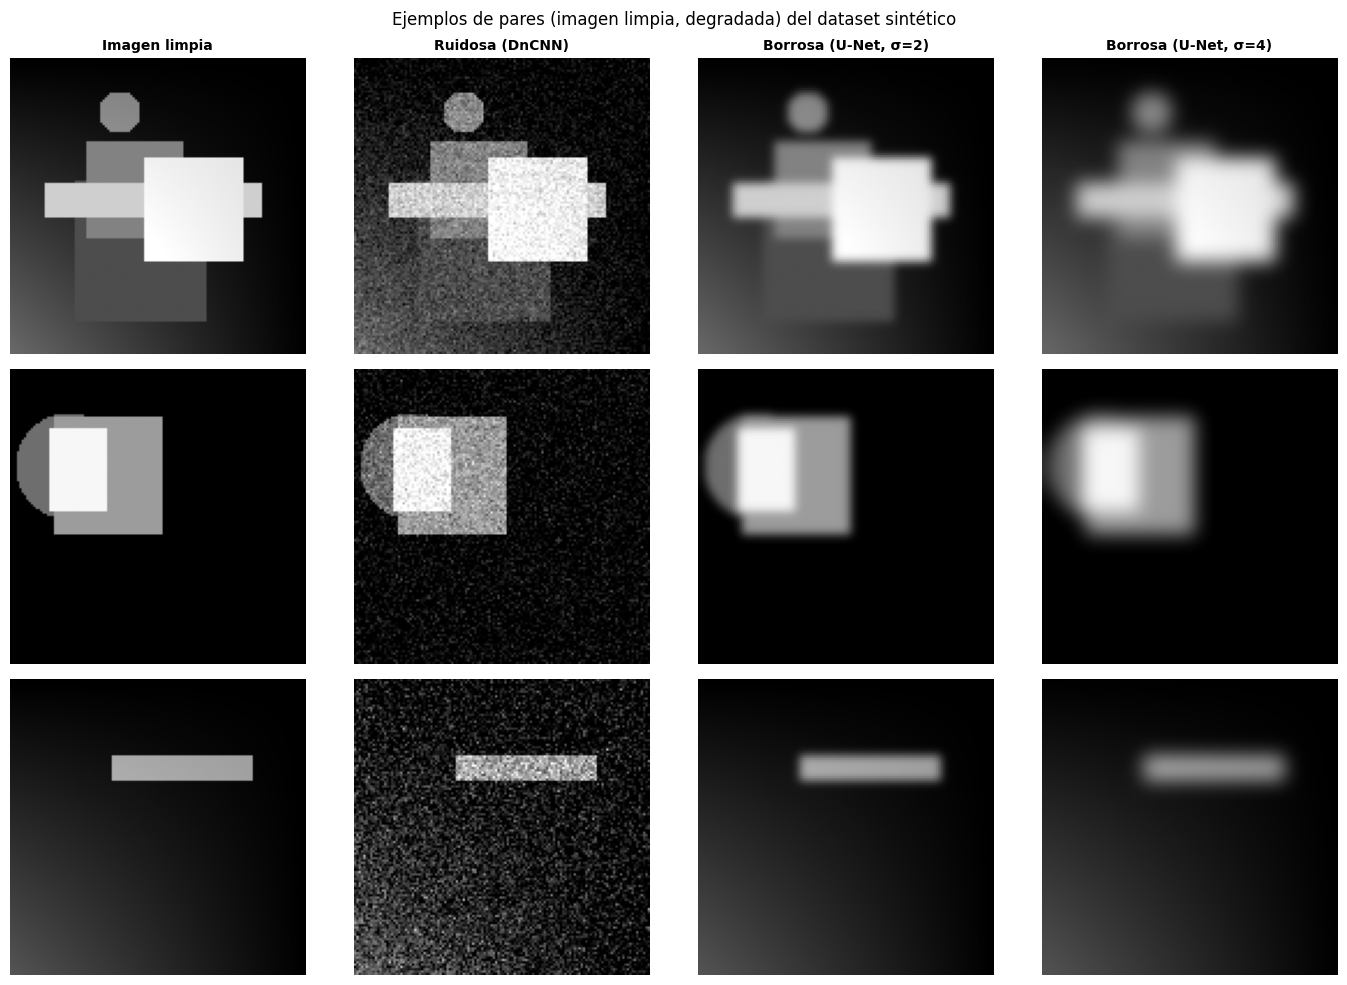

Dataset listo. Los pares se generan al vuelo durante el entrenamiento.


In [6]:
# ── Generador de imágenes sintéticas ─────────────────────────────────────
def make_synthetic_image(size=128, rng=None):
    """Genera una imagen en escala de grises con formas geométricas aleatorias."""
    if rng is None:
        rng = np.random.default_rng()
    img = np.zeros((size, size), dtype=np.float32)
    n_shapes = rng.integers(3, 8)
    for _ in range(n_shapes):
        kind = rng.choice(["rect", "disk", "grad"])
        intensity = float(rng.uniform(0.3, 1.0))
        if kind == "rect":
            r0, c0 = rng.integers(5, size//2, size=2)
            h  = rng.integers(10, size - r0 - 5)
            w  = rng.integers(10, size - c0 - 5)
            img[r0:r0+h, c0:c0+w] = np.maximum(img[r0:r0+h, c0:c0+w], intensity)
        elif kind == "disk":
            cx, cy = rng.integers(20, size-20, size=2)
            r  = rng.integers(8, 25)
            rr, cc = disk((cy, cx), r, shape=(size, size))
            img[rr, cc] = np.maximum(img[rr, cc], intensity)
        else:
            # gradiente diagonal
            g = np.linspace(0, intensity, size)
            img += np.outer(g, np.flip(g)) * 0.3
    return np.clip(img, 0, 1)

# ── PSF gaussiana ─────────────────────────────────────────────────────────
def gaussian_psf(sigma, size=21):
    ax = np.arange(-(size//2), size//2+1, dtype=float)
    xx, yy = np.meshgrid(ax, ax)
    psf = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    return (psf / psf.sum()).astype(np.float32)

# ── Visualizar algunos ejemplos de pares ──────────────────────────────────
rng = np.random.default_rng(0)
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
titles_col = ["Imagen limpia", "Ruidosa (DnCNN)", "Borrosa (U-Net, σ=2)", "Borrosa (U-Net, σ=4)"]
for col, title in enumerate(titles_col):
    axes[0, col].set_title(title, fontsize=10, fontweight="bold")

for row in range(3):
    f_clean = make_synthetic_image(128, rng)
    sigma_n = float(rng.uniform(0.05, 0.25))
    g_noisy = np.clip(f_clean + rng.normal(0, sigma_n, f_clean.shape).astype(np.float32), 0, 1)
    psf2 = gaussian_psf(2)
    psf4 = gaussian_psf(4)
    g_blur2 = np.clip(convolve2d(f_clean, psf2, mode="same", boundary="symm"), 0, 1)
    g_blur4 = np.clip(convolve2d(f_clean, psf4, mode="same", boundary="symm"), 0, 1)

    for col, img in enumerate([f_clean, g_noisy, g_blur2, g_blur4]):
        axes[row, col].imshow(img, vmin=0, vmax=1)
        axes[row, col].axis("off")

plt.suptitle("Ejemplos de pares (imagen limpia, degradada) del dataset sintético", fontsize=12)
plt.tight_layout()
plt.show()

print("Dataset listo. Los pares se generan al vuelo durante el entrenamiento.")


## 5. Entrenamiento del DnCNN para denoising

### Dataset, DataLoader y bucle de entrenamiento

Generamos el dataset al vuelo en cada epoch (augmentación infinita).  
Usamos **MSE Loss** (error cuadrático medio) — equivale a asumir ruido gaussiano,
lo que es consistente con el modelo de degradación del Cap. 3.

$$
\mathcal{L}_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} \| \hat{f}_i - f_i \|^2
$$

**Hiperparámetros de entrenamiento:**
- `lr = 1e-3` — Adam con weight decay 1e-4  
- `batch_size = 8`  
- `epochs = 30` — suficiente para convergencia visible en datos sintéticos  
- `sigma_range = [0.05, 0.25]` — nivel de ruido variable (entrenamiento ciego)


In [7]:
if TORCH_AVAILABLE:
    # ── Dataset ───────────────────────────────────────────────────────────────
    class DenoisingDataset(Dataset):
        def __init__(self, n_samples=400, img_size=128, sigma_range=(0.05, 0.25)):
            self.n = n_samples
            self.size = img_size
            self.sigma_range = sigma_range
            self.rng = np.random.default_rng(1)

        def __len__(self): return self.n

        def __getitem__(self, _):
            f = make_synthetic_image(self.size, self.rng).astype(np.float32)
            sigma = float(self.rng.uniform(*self.sigma_range))
            g = np.clip(f + self.rng.normal(0, sigma, f.shape).astype(np.float32), 0, 1)
            # Shape: (1, H, W) para PyTorch
            return torch.from_numpy(g[None]), torch.from_numpy(f[None])

    train_ds = DenoisingDataset(n_samples=400)
    val_ds   = DenoisingDataset(n_samples=80)
    train_dl = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=8, num_workers=0)

    print(f"Muestras entrenamiento: {len(train_ds)} | validación: {len(val_ds)}")
    print(f"Batches por epoch: {len(train_dl)}")


Muestras entrenamiento: 400 | validación: 80
Batches por epoch: 50


In [8]:
if TORCH_AVAILABLE:
    import time

    dncnn = DnCNN(depth=10, channels=64).to(device)
    optimizer = optim.Adam(dncnn.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.3)
    criterion = nn.MSELoss()

    train_losses, val_losses, val_psnrs = [], [], []
    EPOCHS = 30

    print(f"{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>10} {'Val PSNR':>10} {'Tiempo':>8}")
    print("─" * 55)

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        # ── Entrenamiento ────────────────────────────────────────────────────
        dncnn.train()
        train_loss = 0.0
        for g_batch, f_batch in train_dl:
            g_batch, f_batch = g_batch.to(device), f_batch.to(device)
            optimizer.zero_grad()
            f_hat = dncnn(g_batch)
            loss  = criterion(f_hat, f_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * g_batch.size(0)
        train_loss /= len(train_ds)

        # ── Validación ───────────────────────────────────────────────────────
        dncnn.eval()
        val_loss = 0.0
        psnr_sum = 0.0
        with torch.no_grad():
            for g_batch, f_batch in val_dl:
                g_batch, f_batch = g_batch.to(device), f_batch.to(device)
                f_hat = dncnn(g_batch)
                val_loss += criterion(f_hat, f_batch).item() * g_batch.size(0)
                # PSNR sobre el batch
                for b in range(f_hat.shape[0]):
                    fi = f_batch[b,0].cpu().numpy()
                    fh = f_hat[b,0].cpu().numpy().clip(0,1)
                    psnr_sum += psnr(fi, fh, data_range=1.0)
        val_loss /= len(val_ds)
        val_psnr  = psnr_sum / len(val_ds)

        scheduler.step()
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_psnrs.append(val_psnr)

        if epoch % 5 == 0 or epoch == 1:
            print(f"{epoch:>5}  {train_loss:>12.6f}  {val_loss:>10.6f}  "
                  f"{val_psnr:>9.2f} dB  {time.time()-t0:>6.1f}s")

    print("\n✔ Entrenamiento completo.")


Epoch   Train Loss   Val Loss   Val PSNR   Tiempo
───────────────────────────────────────────────────────
    1      0.043437    0.007284      22.24 dB     2.5s
    5      0.002014    0.002149      26.99 dB     2.2s
   10      0.001690    0.001161      30.02 dB     2.2s
   15      0.001326    0.000974      30.96 dB     2.1s
   20      0.000995    0.000984      30.54 dB     2.1s
   25      0.000909    0.001038      30.76 dB     2.1s
   30      0.000942    0.000804      31.89 dB     2.1s

✔ Entrenamiento completo.


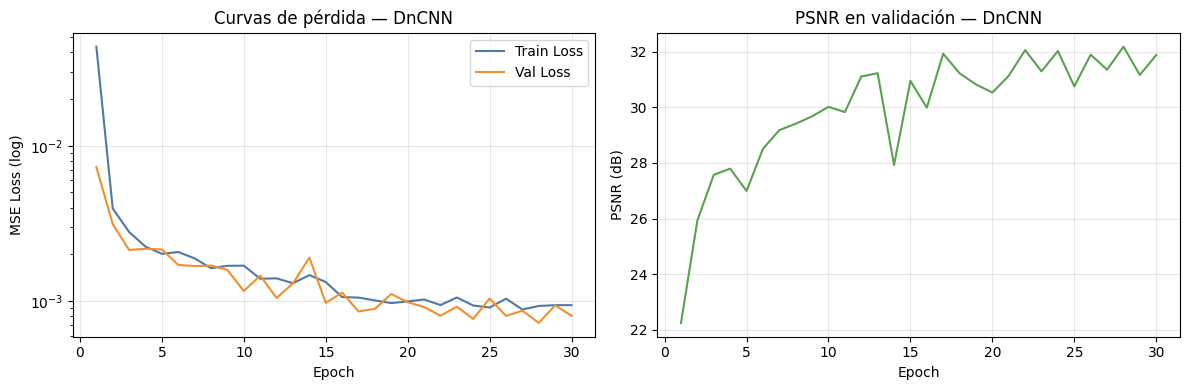

PSNR final en validación: 31.89 dB


In [9]:
if TORCH_AVAILABLE:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    epochs_range = range(1, EPOCHS + 1)

    ax1.plot(epochs_range, train_losses, label="Train Loss", color="#4e79a7")
    ax1.plot(epochs_range, val_losses,   label="Val Loss",   color="#f28e2b")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("MSE Loss (log)")
    ax1.set_yscale("log"); ax1.legend(); ax1.set_title("Curvas de pérdida — DnCNN")
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, val_psnrs, color="#59a14f")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("PSNR (dB)")
    ax2.set_title("PSNR en validación — DnCNN"); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"PSNR final en validación: {val_psnrs[-1]:.2f} dB")


## 6. Entrenamiento de la mini U-Net para deblurring

Para el deblurring el problema es más difícil:
la red debe inferir los detalles de alta frecuencia que la PSF borró.
Las **skip connections** de la U-Net son esenciales aquí.

**Diferencia de loss:** además de MSE usamos una penalización en el **gradiente** de la imagen,
lo que alienta a preservar los bordes:

$$
\mathcal{L} = \text{MSE}(\hat{f}, f) + \lambda \cdot \text{MSE}(\nabla\hat{f}, \nabla f)
$$


In [11]:
if TORCH_AVAILABLE:
    # ── Dataset de deblurring ─────────────────────────────────────────────────
    class DeblurDataset(Dataset):
        def __init__(self, n_samples=400, img_size=128, sigma_range=(1.0, 4.0)):
            self.n = n_samples
            self.size = img_size
            self.sigma_range = sigma_range
            self.rng = np.random.default_rng(2)

        def __len__(self): return self.n

        def __getitem__(self, _):
            f = make_synthetic_image(self.size, self.rng).astype(np.float32)
            sigma = float(self.rng.uniform(*self.sigma_range))
            h = gaussian_psf(sigma, size=21)
            g = convolve2d(f, h, mode="same", boundary="symm").astype(np.float32)
            g = np.clip(g + self.rng.normal(0, 0.01, g.shape).astype(np.float32), 0, 1)
            return torch.from_numpy(g[None]), torch.from_numpy(f[None])

    # ── Loss con penalización de gradiente ────────────────────────────────────
    class GradientLoss(nn.Module):
        def __init__(self, lam=0.1):
            super().__init__()
            self.lam = lam
            self.mse = nn.MSELoss()
            # Kernels de Sobel fijos
            kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
            ky = kx.T
            self.register_buffer("kx", kx.view(1,1,3,3))
            self.register_buffer("ky", ky.view(1,1,3,3))

        def forward(self, pred, target):
            loss_pixel = self.mse(pred, target)
            gx_p = torch.nn.functional.conv2d(pred,   self.kx, padding=1)
            gy_p = torch.nn.functional.conv2d(pred,   self.ky, padding=1)
            gx_t = torch.nn.functional.conv2d(target, self.kx, padding=1)
            gy_t = torch.nn.functional.conv2d(target, self.ky, padding=1)
            loss_grad = self.mse(gx_p, gx_t) + self.mse(gy_p, gy_t)
            return loss_pixel + self.lam * loss_grad

    deblur_train_ds = DeblurDataset(n_samples=400)
    deblur_val_ds   = DeblurDataset(n_samples=80)
    deblur_train_dl = DataLoader(deblur_train_ds, batch_size=8, shuffle=True)
    deblur_val_dl   = DataLoader(deblur_val_ds,   batch_size=8)

    unet      = UNet(base=32).to(device)
    opt_unet  = optim.Adam(unet.parameters(), lr=5e-4, weight_decay=1e-4)
    sched_u   = optim.lr_scheduler.StepLR(opt_unet, step_size=15, gamma=0.3)
    # criterion_u = GradientLoss(lam=0.1)
    criterion_u = GradientLoss(lam=0.1).to(device)  # ← agregar .to(device)

    train_losses_u, val_psnrs_u = [], []
    EPOCHS_U = 30

    print(f"{'Epoch':>5} {'Train Loss':>12} {'Val PSNR':>10}")
    print("─" * 35)

    for epoch in range(1, EPOCHS_U + 1):
        unet.train()
        train_loss = 0.0
        for g_b, f_b in deblur_train_dl:
            g_b, f_b = g_b.to(device), f_b.to(device)
            opt_unet.zero_grad()
            f_hat = unet(g_b)
            loss  = criterion_u(f_hat, f_b)
            loss.backward()
            opt_unet.step()
            train_loss += loss.item() * g_b.size(0)
        train_loss /= len(deblur_train_ds)

        unet.eval()
        psnr_sum = 0.0
        with torch.no_grad():
            for g_b, f_b in deblur_val_dl:
                g_b, f_b = g_b.to(device), f_b.to(device)
                f_hat = unet(g_b).clamp(0, 1)
                for b in range(f_hat.shape[0]):
                    psnr_sum += psnr(f_b[b,0].cpu().numpy(),
                                     f_hat[b,0].cpu().numpy(), data_range=1.0)
        val_psnr = psnr_sum / len(deblur_val_ds)
        sched_u.step()
        train_losses_u.append(train_loss)
        val_psnrs_u.append(val_psnr)
        if epoch % 5 == 0 or epoch == 1:
            print(f"{epoch:>5}  {train_loss:>12.6f}  {val_psnr:>9.2f} dB")

    print("\n✔ Entrenamiento U-Net completo.")


Epoch   Train Loss   Val PSNR
───────────────────────────────────
    1      0.026582      23.64 dB
    5      0.007834      27.53 dB
   10      0.004609      30.55 dB
   15      0.004040      31.99 dB
   20      0.003200      33.00 dB
   25      0.003356      30.19 dB
   30      0.002817      33.81 dB

✔ Entrenamiento U-Net completo.


## 7. Comparación: CNNs vs. métodos clásicos

Evaluamos los cuatro métodos en las mismas imágenes de prueba:

| Tarea | Clásico | CNN |
|---|---|---|
| Denoising | Filtro de Wiener (dominio frecuencial) | DnCNN |
| Deblurring | Filtro de Wiener con PSF exacta | U-Net |

La comparación justa requiere usar la **misma imagen**, la **misma degradación** y
las **mismas métricas** (PSNR y SSIM).


In [13]:
if TORCH_AVAILABLE:
    # ── Funciones de referencia clásicas ─────────────────────────────────────
    def wiener_denoise(g, sigma_n, sigma_f=0.15):
        """Filtro de Wiener simple en frecuencia para denoising."""
        G = np.fft.fft2(g)
        K = (sigma_n**2) / (sigma_f**2)
        f_hat = np.real(np.fft.ifft2(G / (1 + K)))
        return np.clip(f_hat, 0, 1)

    def wiener_deblur(g, h, sigma_n=0.01, sigma_f=0.5):
        """Filtro de Wiener para deblurring con PSF conocida."""
        H = np.fft.fft2(h, s=g.shape)
        G = np.fft.fft2(g)
        K = (sigma_n**2) / (sigma_f**2)
        H_conj = np.conj(H)
        F_hat  = (H_conj * G) / (H_conj * H + K)
        return np.clip(np.real(np.fft.ifft2(F_hat)), 0, 1)

    # ── Imágenes de prueba ────────────────────────────────────────────────────
    rng_test = np.random.default_rng(99)
    results_denoise = []
    results_deblur  = []

    N_TEST = 10
    for _ in range(N_TEST):
        # --- Denoising ---
        f = make_synthetic_image(128, rng_test).astype(np.float32)
        sigma_n = float(rng_test.uniform(0.08, 0.2))
        g_n = np.clip(f + rng_test.normal(0, sigma_n, f.shape).astype(np.float32), 0, 1)

        # Wiener
        f_wiener = wiener_denoise(g_n, sigma_n)

        # DnCNN
        dncnn.eval()
        with torch.no_grad():
            g_t = torch.from_numpy(g_n[None,None]).to(device)
            f_cnn = dncnn(g_t)[0,0].cpu().numpy().clip(0,1)

        results_denoise.append({
            "PSNR entrada": psnr(f, g_n, data_range=1.0),
            "PSNR Wiener":  psnr(f, f_wiener, data_range=1.0),
            "PSNR DnCNN":   psnr(f, f_cnn, data_range=1.0),
            "SSIM Wiener":  ssim(f, f_wiener, data_range=1.0),
            "SSIM DnCNN":   ssim(f, f_cnn, data_range=1.0),
        })

        # --- Deblurring ---
        sigma_b = float(rng_test.uniform(1.5, 3.5))
        h = gaussian_psf(sigma_b)
        g_b = np.clip(convolve2d(f, h, mode="same", boundary="symm") +
                      rng_test.normal(0, 0.01, f.shape).astype(np.float32), 0, 1)

        # Wiener con PSF exacta
        f_wiener_b = wiener_deblur(g_b, h)

        # U-Net
        unet.eval()
        with torch.no_grad():
            g_bt = torch.from_numpy(g_b[None,None]).to(device)
            f_unet = unet(g_bt)[0,0].cpu().numpy().clip(0,1)

        results_deblur.append({
            "PSNR entrada":  psnr(f, g_b,       data_range=1.0),
            "PSNR Wiener":   psnr(f, f_wiener_b, data_range=1.0),
            "PSNR U-Net":    psnr(f, f_unet,     data_range=1.0),
            "SSIM Wiener":   ssim(f, f_wiener_b, data_range=1.0),
            "SSIM U-Net":    ssim(f, f_unet,     data_range=1.0),
        })

# ── Tabla de resultados ────────────────────────────────────────────────────
import pandas as pd

df_d = pd.DataFrame(results_denoise)
df_b = pd.DataFrame(results_deblur)

print("═══ DENOISING ═══")
print(df_d.mean().to_string())
print()
print("═══ DEBLURRING ═══")
print(df_b.mean().to_string())


═══ DENOISING ═══
PSNR entrada    19.696475
PSNR Wiener     15.826191
PSNR DnCNN      32.828101
SSIM Wiener      0.235933
SSIM DnCNN       0.842949

═══ DEBLURRING ═══
PSNR entrada    23.153741
PSNR Wiener     11.093689
PSNR U-Net      32.828320
SSIM Wiener      0.160313
SSIM U-Net       0.915523


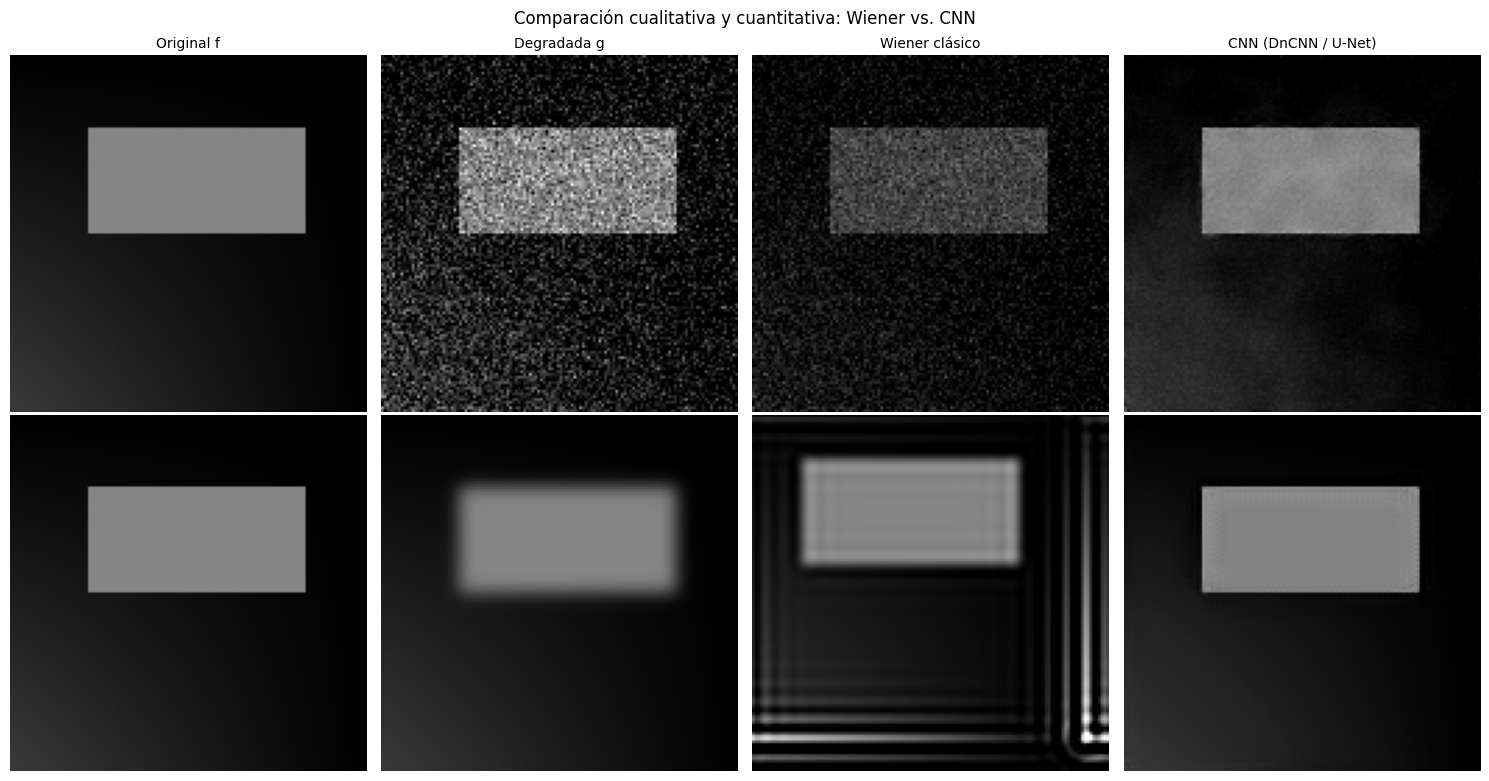

In [14]:
if TORCH_AVAILABLE:
    # ── Visualización cualitativa ──────────────────────────────────────────────
    rng_vis = np.random.default_rng(77)
    f_vis = make_synthetic_image(128, rng_vis).astype(np.float32)

    # Denoising
    sigma_n = 0.15
    g_vis_n = np.clip(f_vis + rng_vis.normal(0, sigma_n, f_vis.shape).astype(np.float32), 0, 1)
    fw_n    = wiener_denoise(g_vis_n, sigma_n)
    dncnn.eval()
    with torch.no_grad():
        fc_n = dncnn(torch.from_numpy(g_vis_n[None,None]).to(device))[0,0].cpu().numpy().clip(0,1)

    # Deblurring
    h_vis    = gaussian_psf(3.0)
    g_vis_b  = np.clip(convolve2d(f_vis, h_vis, mode="same", boundary="symm"), 0, 1)
    fw_b     = wiener_deblur(g_vis_b, h_vis)
    unet.eval()
    with torch.no_grad():
        fc_b = unet(torch.from_numpy(g_vis_b[None,None]).to(device))[0,0].cpu().numpy().clip(0,1)

    # Plot
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    rows = [
        ("DENOISING  (σ=0.15)",  [f_vis, g_vis_n, fw_n,  fc_n]),
        ("DEBLURRING (σ_psf=3)", [f_vis, g_vis_b, fw_b,  fc_b]),
    ]
    col_titles = ["Original f", "Degradada g", "Wiener clásico", "CNN (DnCNN / U-Net)"]

    for row_idx, (row_label, imgs) in enumerate(rows):
        axes[row_idx, 0].set_ylabel(row_label, fontsize=10, fontweight="bold", labelpad=10)
        for col_idx, (img, ctitle) in enumerate(zip(imgs, col_titles)):
            ax = axes[row_idx, col_idx]
            ax.imshow(img, vmin=0, vmax=1)
            ax.axis("off")
            if row_idx == 0:
                ax.set_title(ctitle, fontsize=10)
            if col_idx > 0:
                p = psnr(f_vis, img, data_range=1.0)
                s = ssim(f_vis, img, data_range=1.0)
                ax.set_xlabel(f"PSNR={p:.1f}dB  SSIM={s:.3f}", fontsize=8)

    plt.suptitle("Comparación cualitativa y cuantitativa: Wiener vs. CNN", fontsize=12)
    plt.tight_layout()
    plt.show()


## 8. Limitaciones y falla de generalización

Las CNNs para imaging tienen ventajas claras, pero también **puntos débiles** importantes.

### 8.1 Dependencia del dominio de entrenamiento

Una CNN entrenada con imágenes sintéticas puede fallar con imágenes naturales, médicas o satelitales.  
En el ejemplo siguiente mostramos qué ocurre cuando aplicamos la CNN a un tipo de imagen
para el que no fue entrenada.

### 8.2 La PSF debe ser conocida o cercana a la entrenada

Si entrenamos con σ ∈ [1, 4] y aplicamos la red con σ = 8, la calidad cae drásticamente.

### 8.3 Artefactos en bordes y texturas repetitivas

Las CNNs pueden introducir **artefactos de cuadrícula** (checkerboard artifacts)
o suavizar en exceso las texturas finas. La U-Net con skip connections mitiga esto,
pero no lo elimina completamente.

### 8.4 Coste computacional

Un DnCNN tiene ~500 k parámetros y tarda ~5 ms por imagen en GPU.
En CPU puede ser 50-200× más lento que un filtro de Wiener.


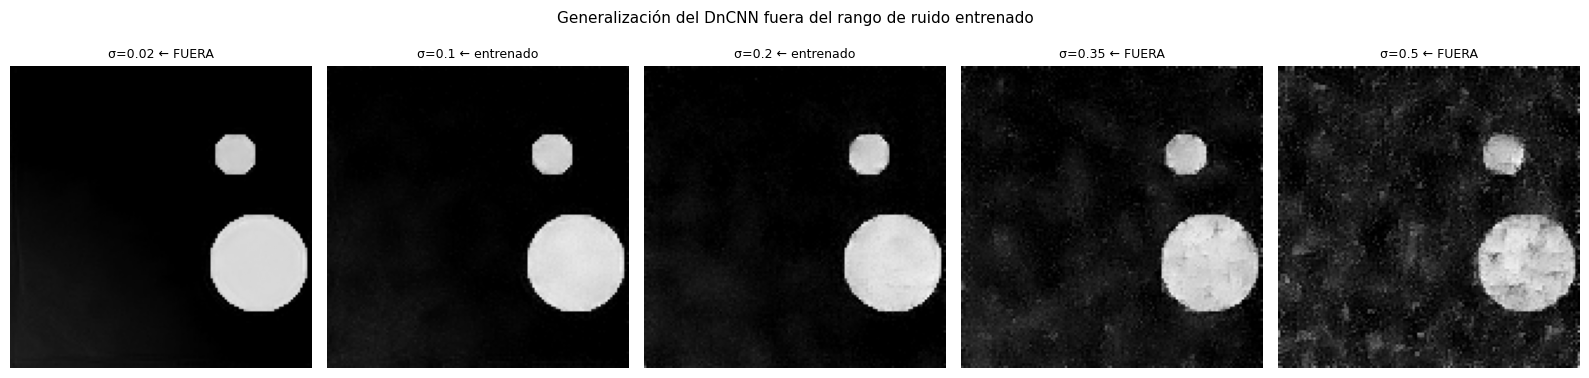

Dentro del rango [0.05, 0.25]: buen resultado.
Fuera del rango: calidad degradada — la red aplica su modelo incorrecto.


In [15]:
if TORCH_AVAILABLE:
    # ── Demostración de falla de generalización fuera del rango de σ ────────
    rng_fail = np.random.default_rng(42)
    f_fail = make_synthetic_image(128, rng_fail).astype(np.float32)

    fig, axes = plt.subplots(1, 5, figsize=(16, 4))
    sigmas_test = [0.02, 0.1, 0.2, 0.35, 0.5]
    titles_fail = [f"σ={s}" + (" ← entrenado" if 0.05<=s<=0.25 else " ← FUERA") for s in sigmas_test]

    for ax, sigma_t, title_f in zip(axes, sigmas_test, titles_fail):
        g_fail = np.clip(f_fail + rng_fail.normal(0, sigma_t, f_fail.shape).astype(np.float32), 0, 1)
        dncnn.eval()
        with torch.no_grad():
            fc_fail = dncnn(torch.from_numpy(g_fail[None,None]).to(device))[0,0].cpu().numpy().clip(0,1)
        p = psnr(f_fail, fc_fail, data_range=1.0)
        ax.imshow(fc_fail, vmin=0, vmax=1)
        ax.set_title(title_f, fontsize=9)
        ax.set_xlabel(f"PSNR={p:.1f}dB", fontsize=8)
        ax.axis("off")

    plt.suptitle("Generalización del DnCNN fuera del rango de ruido entrenado", fontsize=11)
    plt.tight_layout()
    plt.show()
    print("Dentro del rango [0.05, 0.25]: buen resultado.")
    print("Fuera del rango: calidad degradada — la red aplica su modelo incorrecto.")


## 9. Ejercicios sugeridos

1. **Profundidad del DnCNN**: cambia `depth` a 5 y a 20. Compara PSNR final y tiempo
   de entrenamiento. ¿Hay overfitting con D=20?

2. **Pérdida perceptual**: reemplaza el MSE Loss por una combinación de MSE + SSIM loss.
   La SSIM loss es: $\mathcal{L}_{SSIM} = 1 - \text{SSIM}(\hat{f}, f)$.  
   Implementa `SSIMLoss` usando la función `ssim` de `pytorch_ssim` o implementa
   la fórmula directamente.

3. **PSF variable en entrenamiento de U-Net**: en el `DeblurDataset`, además de σ variable,
   usa también PSFs de movimiento (motion blur con distintos ángulos y longitudes).
   ¿Cómo afecta al PSNR para PSFs que nunca vio?

4. **Blind deblurring**: entrena la U-Net sin pasarle explícitamente la σ de la PSF.
   ¿Puede aprender a deconvolucionar PSFs desconocidas? Compara con un modelo que
   recibe la σ como canal adicional de entrada.

5. **Imagen natural**: descarga una imagen de `skimage.data.camera()` o `skimage.data.astronaut()`,
   aplica el DnCNN y la U-Net, y compara visualmente con Wiener. ¿Qué artefactos ves?

6. **Comparación de velocidad**: mide con `time.time()` el tiempo de inferencia
   del DnCNN vs. el filtro de Wiener en numpy para 100 imágenes de 512×512.
   ¿Cuál es el factor de diferencia?


## 10. Conclusiones

En este capítulo pasamos del mundo de los métodos clásicos al mundo del aprendizaje profundo
aplicado a la restauración de imagen.

### Resumen comparativo

| Aspecto | Métodos clásicos (Wiener, RL) | CNNs (DnCNN, U-Net) |
|---|---|---|
| **Conocimiento de PSF** | Necesario (o estimado) | No necesario si entrenada con diversidad |
| **Modelo de ruido** | Explícito (gaussiano, Poisson) | Implícito (aprendido) |
| **Velocidad de inferencia** | Muy rápida (ms, CPU) | Rápida en GPU, lenta en CPU |
| **Calidad** | Buena con PSF exacta | Superior en dominio de entrenamiento |
| **Generalización** | Muy alta (no depende de datos) | Limitada al dominio de entrenamiento |
| **Interpretabilidad** | Alta (ecuaciones conocidas) | Baja (caja negra) |

### Ideas clave

- El **residual learning** (aprender el ruido/blur, no la imagen limpia) acelera la convergencia
  y mejora los resultados finales.
- Las **skip connections** de la U-Net permiten recuperar detalles de alta frecuencia
  que el encoder descartó.
- La **pérdida de gradiente** (Sobel) complementa el MSE al preservar bordes.
- Las CNNs no generalizan bien fuera del rango de degradaciones del entrenamiento.
- La solución práctica moderna combina ambos mundos: **deep unfolding** o **plug-and-play priors**,
  donde una CNN actúa como prior y un optimizador clásico resuelve el problema inverso.

---

### Próximo notebook

**Capítulo 5 — Estimación de PSF y deconvolución ciega (Blind Deconvolution)**  
¿Qué hacemos cuando no conocemos la PSF?  
Veremos métodos para estimar $h(x,y)$ directamente desde la imagen degradada,
combinando máxima verosimilitud, gradiente alternado y redes especializadas.
